# AI-Powered Global Retail Sales Forecasting & Business Intelligence Platform

### Author
Prasitha

### Project Type
Machine Learning | Business Analytics | Sales Forecasting

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- XGBoost
- Streamlit
- Power BI
- GitHub

### Dataset
Global Superstore Orders Dataset

# Problem Statement

Retail companies generate large volumes of sales data across products, regions, and markets. Accurate forecasting helps organizations improve inventory planning, revenue management, staffing decisions, and strategic business planning.

This project analyzes historical retail sales data and develops machine learning models to forecast future sales and profits while generating actionable business insights.

# Project Objectives

1. Understand business performance
2. Analyze sales and profit trends
3. Identify top-performing products
4. Analyze regional performance
5. Forecast future sales
6. Forecast future profits
7. Build interactive dashboards
8. Develop a Streamlit forecasting application
9. Generate business recommendations

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import joblib

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [4]:
import os

os.listdir()

['.config', 'SuperStoreOrders.csv.zip', 'sample_data']

In [5]:
import zipfile

with zipfile.ZipFile('SuperStoreOrders.csv.zip', 'r') as zip_ref:
    zip_ref.extractall()

print("ZIP file extracted successfully!")

ZIP file extracted successfully!


In [6]:
import os

print(os.listdir())

['.config', 'SuperStoreOrders.csv.zip', 'SuperStoreOrders.csv', 'sample_data']


In [7]:
df = pd.read_csv('SuperStoreOrders.csv')

In [8]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [9]:
df.shape

(51290, 21)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [11]:
df['sales'].head()

,sales
0,408
1,120
2,66
3,45
4,114


In [12]:
df['sales'].dtype

dtype('O')

In [13]:
df['sales'].sample(10)

,sales
19791,51
43885,38
46619,80
27799,106
15877,27
32352,43
31508,17
16616,20
33645,3
833,151


In [14]:
df['sales'].tail()

,sales
51285,14
51286,4
51287,26
51288,7
51289,3


In [16]:
df['sales'] = df['sales'].str.replace(',', '')

In [17]:
df['sales'] = pd.to_numeric(df['sales'])

In [18]:
df['sales'].dtype

dtype('int64')

In [20]:
df['order_date'] = pd.to_datetime(
    df['order_date'],
    format='mixed',
    dayfirst=True
)

df['ship_date'] = pd.to_datetime(
    df['ship_date'],
    format='mixed',
    dayfirst=True
)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           51290 non-null  int64         
 15  qu

In [22]:
df['Month'] = df['order_date'].dt.month

df['Quarter'] = df['order_date'].dt.quarter

df['Day'] = df['order_date'].dt.day

df['Weekday'] = df['order_date'].dt.day_name()

df['Shipping_Days'] = (
    df['ship_date'] - df['order_date']
).dt.days

df['Profit_Margin'] = (
    df['profit'] / df['sales']
) * 100

In [23]:
df[['sales',
    'profit',
    'Profit_Margin',
    'Month',
    'Quarter',
    'Shipping_Days']].head()

,sales,profit,Profit_Margin,Month,Quarter,Shipping_Days
0,408,106.140,26.014706,1,1,5
1,120,36.036,30.030000,1,1,7
2,66,29.640,44.909091,1,1,4
3,45,-26.055,-57.900000,1,1,4
4,114,37.770,33.131579,1,1,7


In [24]:
total_sales = df['sales'].sum()
print("Total Sales =", total_sales)

Total Sales = 12642905


In [25]:
total_profit = df['profit'].sum()
print("Total Profit =", total_profit)

Total Profit = 1469034.8212799998


In [26]:
total_orders = df['order_id'].nunique()
print("Total Orders =", total_orders)

Total Orders = 25035


In [27]:
total_customers = df['customer_name'].nunique()
print("Total Customers =", total_customers)

Total Customers = 795


In [28]:
avg_profit_margin = df['Profit_Margin'].mean()
print("Average Profit Margin =", avg_profit_margin)

Average Profit Margin = -inf


# Key Performance Indicators (KPIs)

The KPI analysis provides a summary of overall business performance.

Metrics analyzed:

- Total Sales
- Total Profit
- Total Orders
- Total Customers
- Average Profit Margin

These indicators help understand the company's revenue generation, profitability, customer base, and operational performance.

In [29]:
(df['sales'] == 0).sum()

np.int64(1)

In [30]:
import numpy as np

df['Profit_Margin'] = np.where(
    df['sales'] > 0,
    (df['profit'] / df['sales']) * 100,
    0
)

In [31]:
avg_profit_margin = df['Profit_Margin'].mean()

print(avg_profit_margin)

4.7207058215659305


# KPI Insights

The Global Superstore business generated total sales of 12.64 million and total profits of 1.47 million from 25,035 unique orders placed by 795 customers.

The average profit margin of 4.72% indicates that the company operates profitably while managing discounts, shipping costs, and operational expenses.

These KPIs provide a high-level overview of business performance and establish a foundation for further sales and profitability analysis.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to identify trends, patterns, and relationships within the sales data.

The objective is to gain business insights that can support strategic decision-making and improve forecasting accuracy.

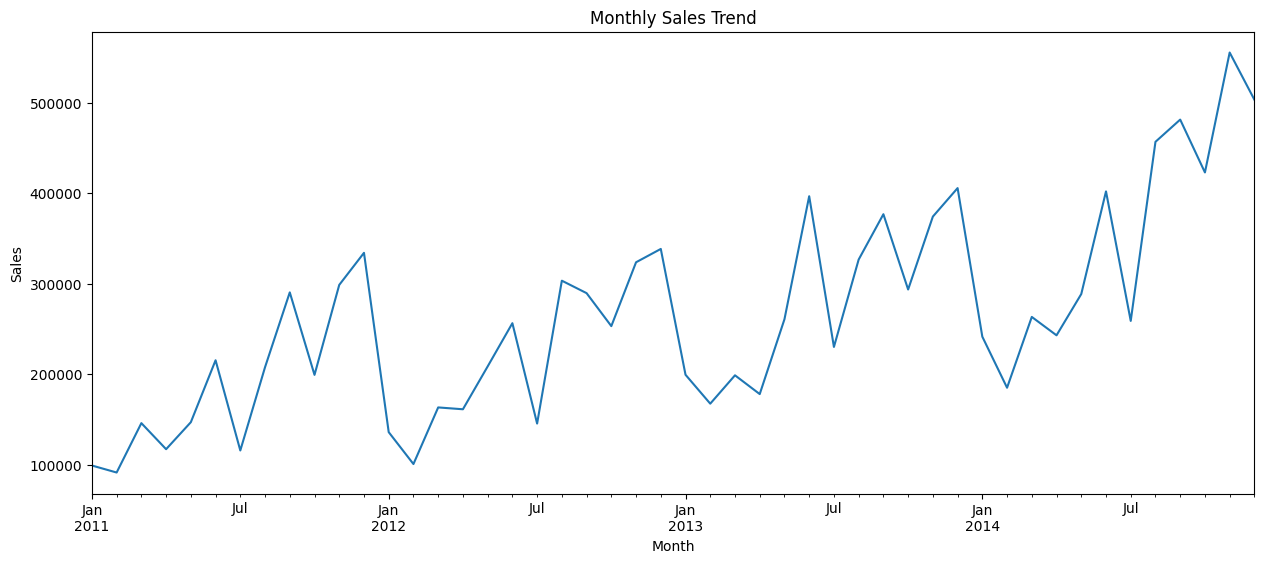

In [32]:
monthly_sales = df.groupby(
    df['order_date'].dt.to_period('M')
)['sales'].sum()

plt.figure(figsize=(15,6))

monthly_sales.plot()

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.show()

## Yearly Sales Trend

This visualization shows how overall sales have changed across different years.

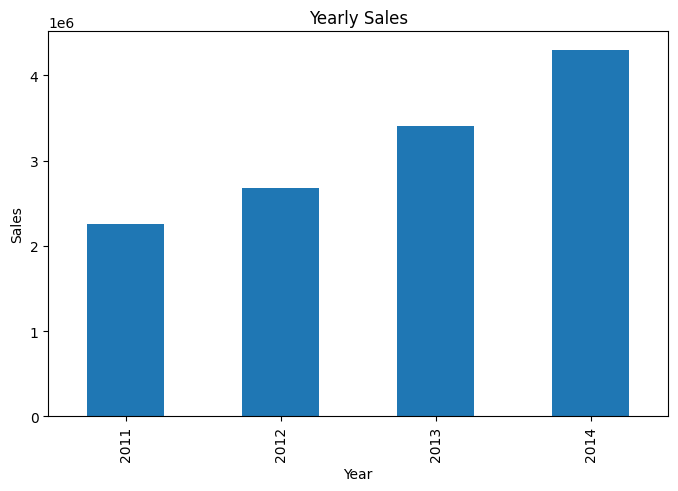

In [33]:
yearly_sales = df.groupby('year')['sales'].sum()

plt.figure(figsize=(8,5))

yearly_sales.plot(kind='bar')

plt.title('Yearly Sales')
plt.xlabel('Year')
plt.ylabel('Sales')

plt.show()

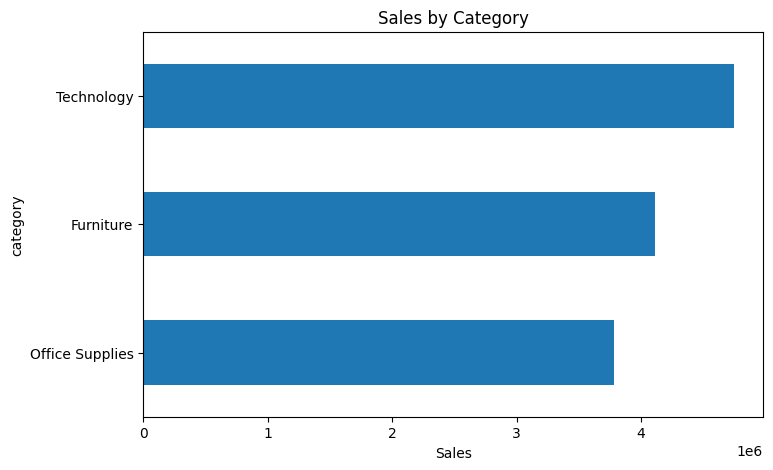

In [34]:
category_sales = df.groupby(
    'category'
)['sales'].sum().sort_values()

plt.figure(figsize=(8,5))

category_sales.plot(kind='barh')

plt.title('Sales by Category')
plt.xlabel('Sales')

plt.show()

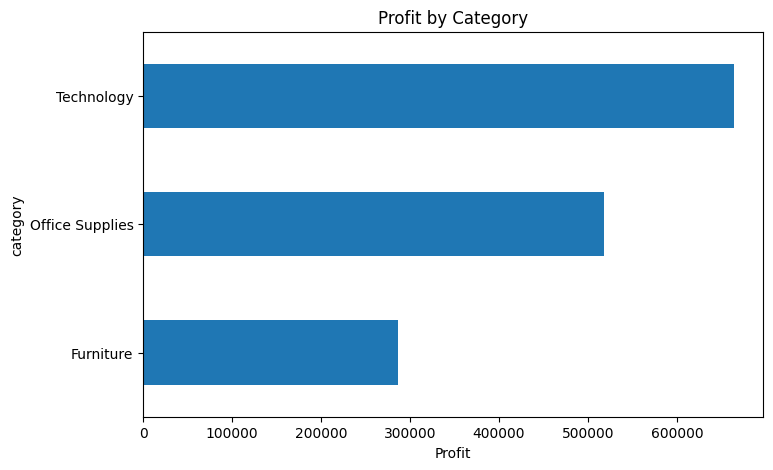

In [35]:
category_profit = df.groupby(
    'category'
)['profit'].sum().sort_values()

plt.figure(figsize=(8,5))

category_profit.plot(kind='barh')

plt.title('Profit by Category')
plt.xlabel('Profit')

plt.show()

# Category Analysis Insights

Technology is the most valuable category, contributing the highest sales and profit.

Furniture generates strong revenue but lower profit margins compared to other categories, indicating opportunities for cost optimization.

Office Supplies provide stable profitability and serve as a consistent revenue stream.

The business should prioritize Technology products while investigating strategies to improve Furniture profitability.

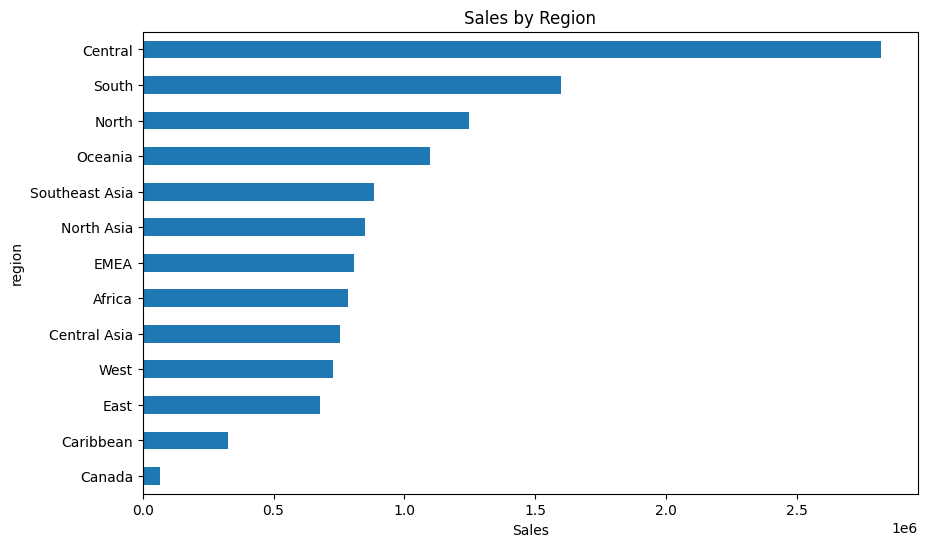

In [36]:
region_sales = df.groupby('region')['sales'].sum().sort_values()

plt.figure(figsize=(10,6))

region_sales.plot(kind='barh')

plt.title('Sales by Region')
plt.xlabel('Sales')

plt.show()

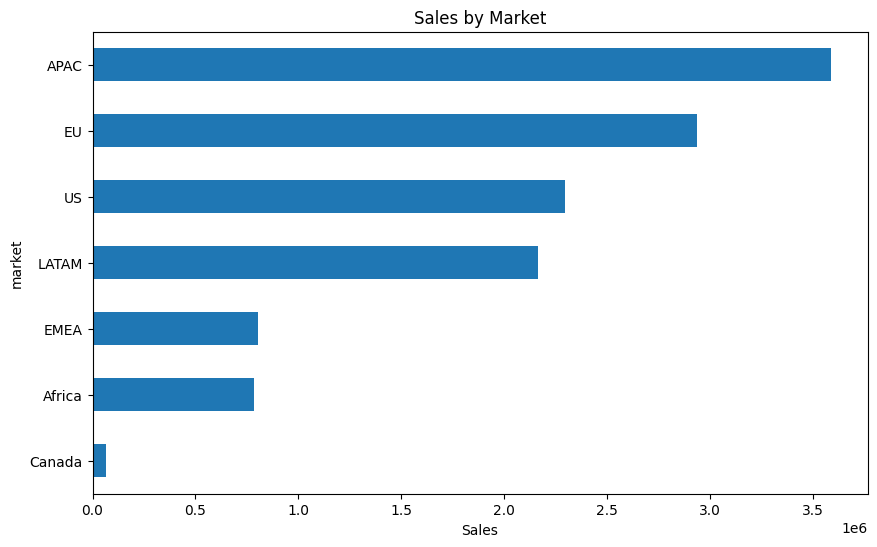

In [37]:
market_sales = df.groupby('market')['sales'].sum().sort_values()

plt.figure(figsize=(10,6))

market_sales.plot(kind='barh')

plt.title('Sales by Market')
plt.xlabel('Sales')

plt.show()

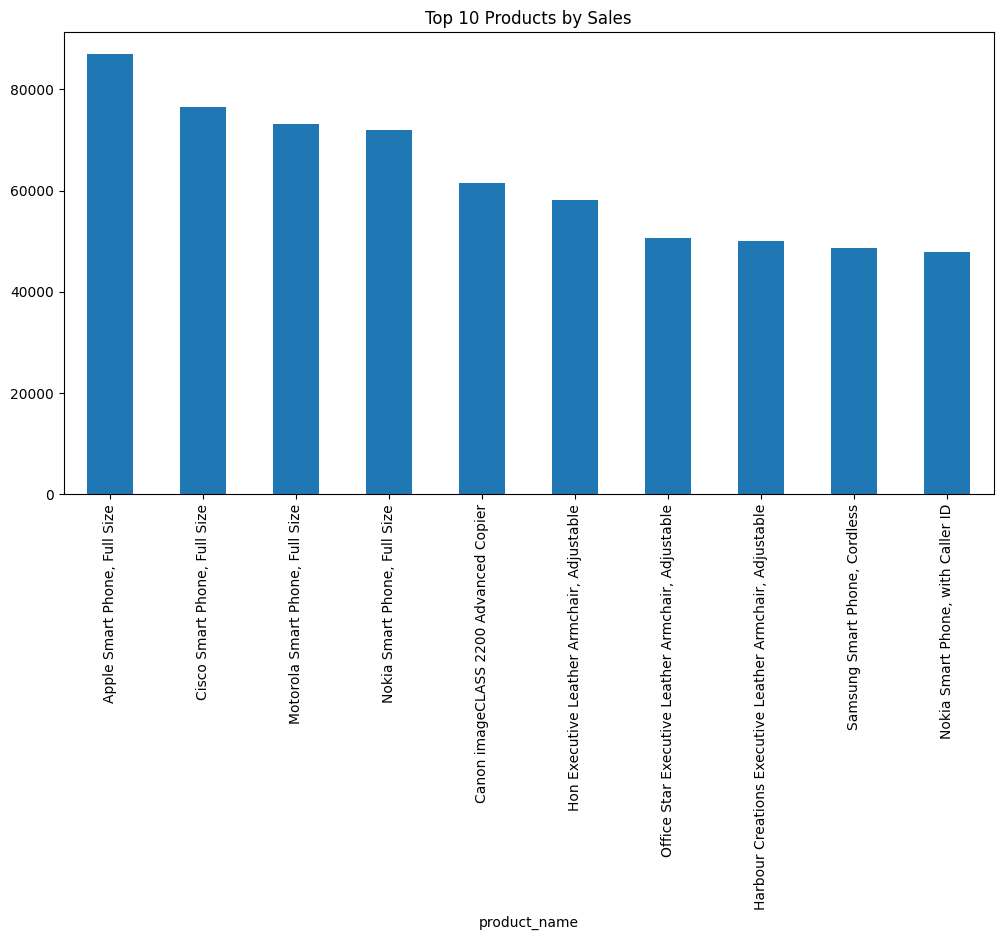

In [38]:
top_products = df.groupby(
    'product_name'
)['sales'].sum().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title('Top 10 Products by Sales')

plt.show()

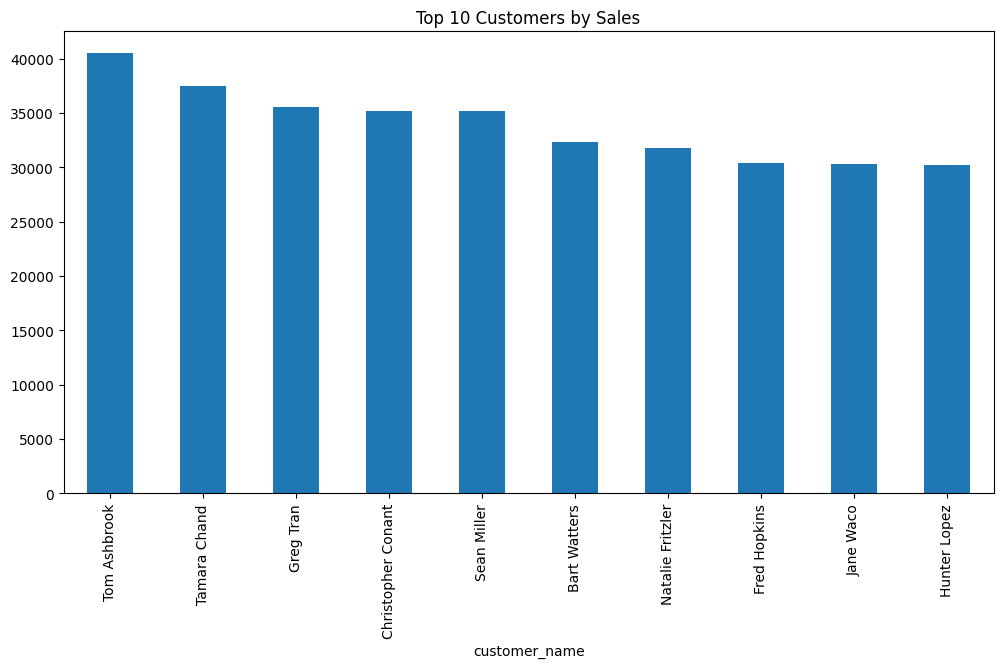

In [39]:
top_customers = df.groupby(
    'customer_name'
)['sales'].sum().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

top_customers.plot(kind='bar')

plt.title('Top 10 Customers by Sales')

plt.show()

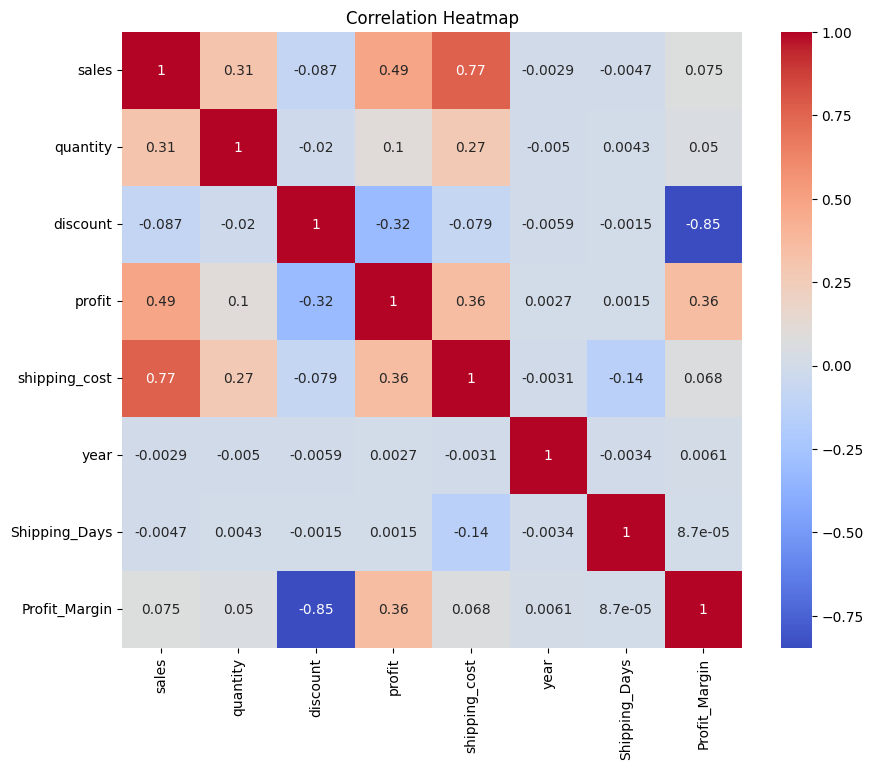

In [40]:
import seaborn as sns

numeric_df = df.select_dtypes(
    include=['int64','float64']
)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

# Regional and Market Analysis

The Central region generated the highest sales among all regions, making it the most valuable geographic area for the business.

Among markets, APAC contributed the largest share of revenue followed by Europe and the United States.

Lower-performing regions such as Canada and Africa present opportunities for future market expansion.

# Correlation Analysis

Correlation analysis was performed to identify relationships among numerical variables.

Key findings include:

- Sales and profit show a positive relationship.
- Shipping cost increases with sales volume.
- Discounts negatively impact profitability.
- Profit margin is strongly reduced when higher discounts are offered.

These findings suggest that discount optimization can significantly improve overall business profitability.

In [41]:
monthly_forecast_data = df.groupby(
    df['order_date'].dt.to_period('M')
)['sales'].sum().reset_index()

monthly_forecast_data['order_date'] = monthly_forecast_data[
    'order_date'
].astype(str)

monthly_forecast_data.head()

,order_date,sales
0,2011-01,98902
1,2011-02,91152
2,2011-03,145726
3,2011-04,116927
4,2011-05,146762


In [42]:
monthly_forecast_data.head()

,order_date,sales
0,2011-01,98902
1,2011-02,91152
2,2011-03,145726
3,2011-04,116927
4,2011-05,146762


In [43]:
monthly_forecast_data['order_date'] = pd.to_datetime(
    monthly_forecast_data['order_date']
)

monthly_forecast_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   order_date  48 non-null     datetime64[ns]
 1   sales       48 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 900.0 bytes


# Time Series Analysis

The monthly sales trend is visualized to understand seasonality, growth patterns, and long-term business performance.

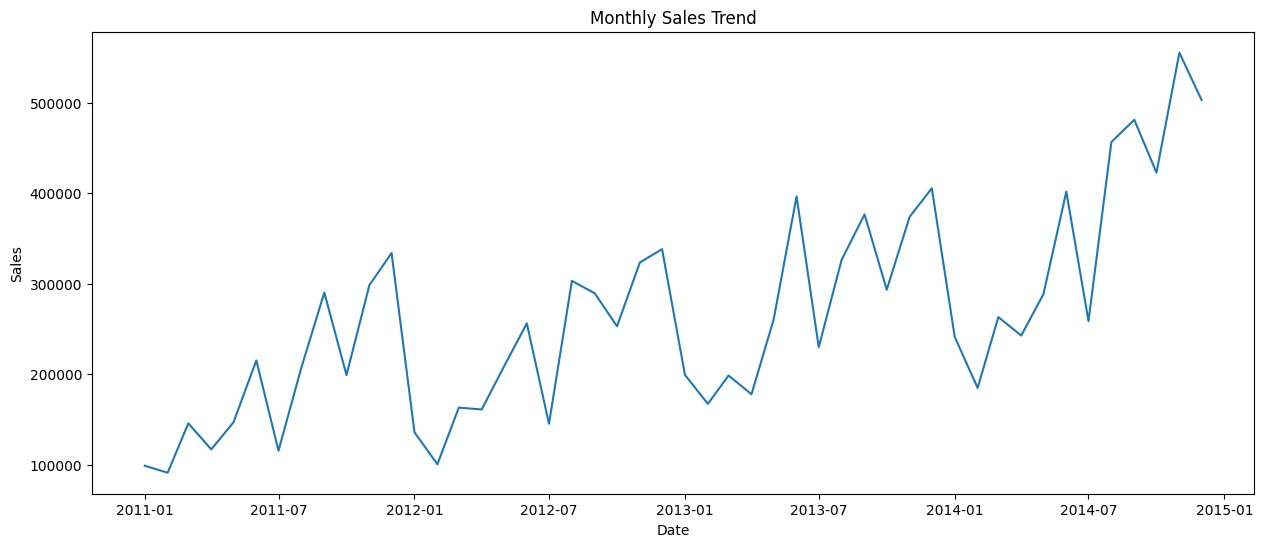

In [44]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_forecast_data['order_date'],
    monthly_forecast_data['sales']
)

plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.show()

In [45]:
train_size = int(
    len(monthly_forecast_data) * 0.8
)

train = monthly_forecast_data[:train_size]

test = monthly_forecast_data[train_size:]

print("Train Size:", len(train))
print("Test Size:", len(test))

Train Size: 38
Test Size: 10


In [46]:
!pip install prophet

In [47]:
prophet_df = monthly_forecast_data.rename(
    columns={
        'order_date':'ds',
        'sales':'y'
    }
)

prophet_df.head()

,ds,y
0,2011-01-01,98902
1,2011-02-01,91152
2,2011-03-01,145726
3,2011-04-01,116927
4,2011-05-01,146762


In [48]:
from prophet import Prophet

model = Prophet()

model.fit(prophet_df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [49]:
future = model.make_future_dataframe(
    periods=12,
    freq='M'
)

forecast = model.predict(future)

forecast[['ds','yhat']].tail(12)

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,yhat
48,2014-12-31,296511.715053
49,2015-01-31,302962.575514
50,2015-02-28,426080.771155
51,2015-03-31,380460.150610
52,2015-04-30,393214.540123
53,2015-05-31,505490.364768
54,2015-06-30,396681.384695
55,2015-07-31,467618.011065
56,2015-08-31,630380.830051
57,2015-09-30,471494.537727


# Forecasting Insights

The forecasting model predicts continued sales growth throughout 2015.

Sales are expected to peak during August, October, and November, indicating strong seasonal demand during these periods.

The forecast suggests that inventory planning, marketing campaigns, and staffing decisions should be aligned with these high-demand months to maximize revenue opportunities.

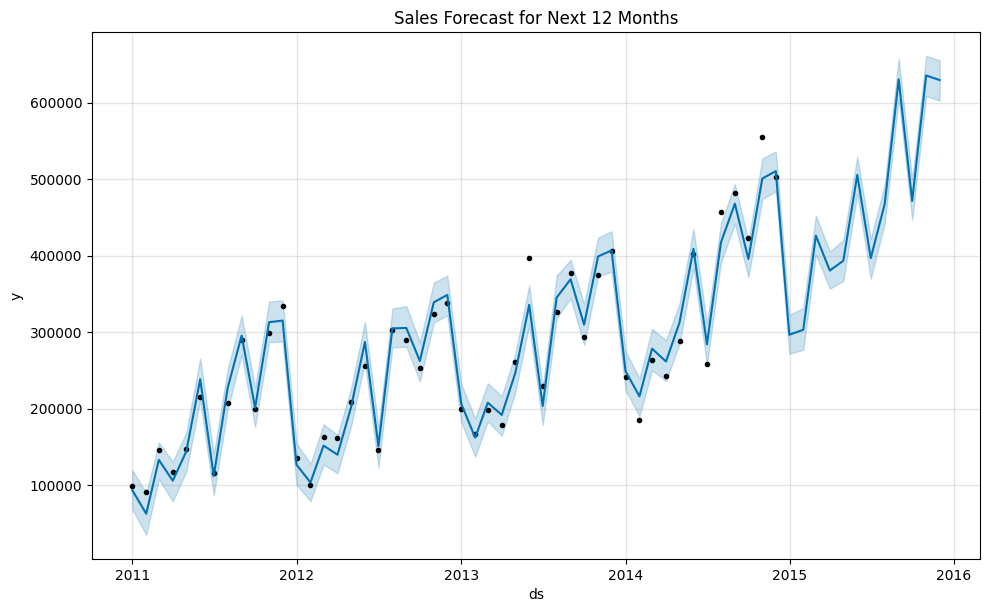

In [50]:
fig = model.plot(forecast)

plt.title('Sales Forecast for Next 12 Months')

plt.show()

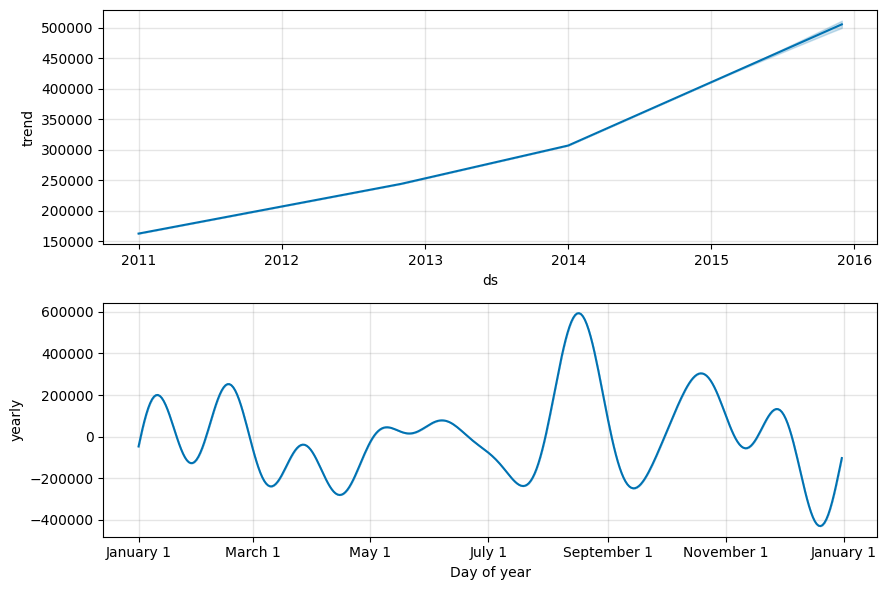

In [51]:
fig2 = model.plot_components(forecast)

plt.show()

In [52]:
from sklearn.metrics import mean_absolute_error

actual = prophet_df['y']

predicted = forecast['yhat'][:len(actual)]

mae = mean_absolute_error(
    actual,
    predicted
)

print("MAE:", mae)

MAE: 15936.832510510327


In [53]:
import pickle

pickle.dump(
    model,
    open('sales_forecast_model.pkl', 'wb')
)

# Model Evaluation

The Prophet forecasting model was evaluated using Mean Absolute Error (MAE).

MAE Score: 15,936.83

The relatively low prediction error compared to the overall sales volume indicates that the model is capable of capturing the underlying sales trend and seasonality patterns effectively.

This forecasting model can support inventory planning, sales target setting, budgeting, and strategic business decision-making.